<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Regresión Polinomial y Técnicas de Regularización 🛡️
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 07
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
### 1. Regresión Polinomial 🎢

Una estrategia común para incrementar la capacidad representativa de los modelos lineales cuando los datos exhiben relaciones no lineales es transformar las características originales mediante **funciones no lineales polinomiales**.

#### 1.1 Intuición Geométrica (De Planos a Superficies Curvas):
* En el caso de dos variables predictoras $(x_1, x_2)$, la regresión lineal estándar ajusta un **hiperplano bidimensional**:
  $$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2$$
* Si combinamos las características en un polinomio de segundo orden ($d=2$), ajustamos una **superficie parabólica (paraboloide)**:
  $$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1^2 + \beta_4 x_2^2 + \beta_5 x_1 x_2$$

> 💡 **Principio Fundamental:**  
> Aunque la relación respecto a las variables $x$ es cuadrática o cúbica, **el modelo matemático sigue siendo estrictamente lineal en los parámetros $\beta$**. Por ende, se puede estimar analíticamente utilizando la misma maquinaria de Mínimos Cuadrados Ordinarios (OLS).

---
### 2. Expansión Polinomial con `PolynomialFeatures` en Scikit-Learn 🛠️

`sklearn.preprocessing.PolynomialFeatures` genera matrices de características ampliadas conteniendo todas las combinaciones polinomiales de grado menor o igual al especificado.

* **Ejemplo con 3 características $(x_1, x_2, x_3)$ y grado $d=2$:**  
  Genera 9 términos: $x_1, x_2, x_3, x_1^2, x_1 x_2, x_1 x_3, x_2^2, x_2 x_3, x_3^2$.
* **El parámetro `include_bias`:**
  * Por defecto `include_bias=True` añade una columna inicial de unos ($x_0 = 1$), lo que representa el término constante $\beta_0$.
  * En la práctica, se recomienda configurar `include_bias=False` y permitir que el estimador `LinearRegression(fit_intercept=True)` maneje el intercepto de forma automática.

In [1]:
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado, preprocesamiento y regularización
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["font.size"] = 10

np.random.seed(42)
print("✅ Entorno configurado para Regresión Polinomial y Regularización.")

✅ Entorno configurado para Regresión Polinomial y Regularización.


In [2]:
# 1. Carga del conjunto de datos Advertising
adv_data = pd.read_csv("data/Advertising.csv")
if 'Unnamed: 0' in adv_data.columns:
    adv_data = adv_data[['TV', 'Radio', 'Newspaper', 'Sales']]

X_features = ['TV', 'Radio', 'Newspaper']
X = adv_data[X_features].to_numpy()
y = adv_data['Sales'].to_numpy()

# 2. Partición Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=23)

# 3. Transformación Polinomial de Grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("=" * 60)
print(f"Dimensiones Originales:     X_train: {X_train.shape}  | X_test: {X_test.shape}")
print(f"Dimensiones con Polinomio:  X_train: {X_train_poly.shape}  | X_test: {X_test_poly.shape}")
print("=" * 60)
print("Nuevas características generadas:")
for name in poly.get_feature_names_out(X_features):
    print(f" • {name}")

Dimensiones Originales:     X_train: (140, 3)  | X_test: (60, 3)
Dimensiones con Polinomio:  X_train: (140, 9)  | X_test: (60, 9)
Nuevas características generadas:
 • TV
 • Radio
 • Newspaper
 • TV^2
 • TV Radio
 • TV Newspaper
 • Radio^2
 • Radio Newspaper
 • Newspaper^2


In [3]:
# Ajuste del modelo de regresión lineal sobre las características polinomiales
lin_reg_poly = LinearRegression(fit_intercept=True)
lin_reg_poly.fit(X_train_poly, y_train)

# Evaluación sobre el conjunto de test
y_pred_poly = lin_reg_poly.predict(X_test_poly)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("=" * 55)
print("📊 RESULTADOS DEL MODELO POLINOMIAL (GRADO 2):")
print("=" * 55)
print(f"• Coeficiente R² en Test:  {r2_poly:.4f} (98.7% varianza explicada)")
print(f"• Error RMSE en Test:      {rmse_poly:.4f} (miles de unidades)")
print("=" * 55)

📊 RESULTADOS DEL MODELO POLINOMIAL (GRADO 2):
• Coeficiente R² en Test:  0.9933 (98.7% varianza explicada)
• Error RMSE en Test:      0.4871 (miles de unidades)


---
### 3. Técnicas de Regularización: Controlando la Complejidad 🛡️

A medida que aumentamos el grado del polinomio o agregamos muchas variables, el número de características $p$ crece rápidamente. Si el número de observaciones $n$ no es mucho mayor que $p$, las estimaciones de mínimos cuadrados ordinarios tendrán una **varianza excesivamente alta** (*Overfitting*).

La **Regularización (*Shrinkage*)** es una técnica embebida que penaliza los coeficientes grandes, contrayéndolos hacia cero para lograr dos objetivos esenciales:

1. **Mayor Precisión Predictiva:** Reduce drásticamente la varianza del modelo a cambio de un incremento despreciable en el sesgo.
2. **Mayor Interpretabilidad:** Elimina o atenúa el impacto de variables irrelevantes o redundantes.

---

### 3.1 Regresión Ridge (Penalización $L_2$) 🔵

En la regresión lineal estándar minimizamos la Suma de Errores al Cuadrado ($\text{RSS}$):

$$\text{RSS} = \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2$$

En la **Regresión Ridge**, añadimos un término de penalización cuadrático sobre los coeficientes (*Shrinkage Penalty*):

$$\sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^p \beta_j^2 = \text{RSS} + \lambda \sum_{j=1}^p \beta_j^2$$

Donde:
* $\lambda \ge 0$ (denotado como `alpha` en Scikit-Learn) es el **hiperparámetro de ajuste (*tuning parameter*)**.
* Cuando $\lambda = 0$, Ridge equivale exactamente a MCO / OLS estándar.
* A medida que $\lambda \to \infty$, la penalización crece forzando a los coeficientes $\beta_j \to 0$ (pero sin llegar a anularlos exactamente).

---

### 3.2 Regresión Lasso (Penalización $L_1$) 🔴

La regresión Ridge contrae todos los coeficientes hacia cero, pero **no anula ninguno exactamente a cero**. Si el objetivo es realizar **selección automática de características**, empleamos **Lasso (*Least Absolute Shrinkage and Selection Operator*)**:

$$\sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^p |\beta_j| = \text{RSS} + \lambda \sum_{j=1}^p |\beta_j|$$

Donde $\lambda \sum_{j=1}^p |\beta_j|$ es la **penalización $L_1$**.  
Gracias a la geometría de la norma $L_1$, Lasso forza a cero exacto ($\beta_j = 0$) a los coeficientes de las variables irrelevantes, generando modelos dispersos (*sparse models*) y altamente interpretables.

---
### 4. Consideraciones Críticas: Estandarización y el Trade-off con $\lambda$ ⚖️

#### 4.1 Requisito Obligatorio: Estandarización de Variables (*Feature Scaling*):
A diferencia de OLS (que es invariante a la escala de las variables), las penalizaciones Ridge ($L_2$) y Lasso ($L_1$) **dependen directamente de la magnitud numérica de los predictores**. Por tanto, es indispensable estandarizar las características antes del ajuste:

$$\tilde{x}_{ij} = \frac{x_{ij} - \bar{x}_j}{\sqrt{\frac{1}{n} \sum_{i=1}^n (x_{ij} - \bar{x}_j)^2}} = \frac{x_{ij} - \bar{x}_j}{\sigma_j}$$

#### 4.2 Efecto del Hiperparámetro $\lambda$ sobre el Sesgo y la Varianza:
* A medida que $\lambda$ aumenta: la flexibilidad del modelo disminuye, logrando una **menor varianza** pero aumentando el **sesgo**.
* Existe un valor óptimo $\lambda^*$ que minimiza el error cuadrático medio global sobre datos no vistos.

---
### 5. ¿Cuándo Elegir Ridge y cuándo Lasso? 🔀

* **Lasso ($L_1$):** Es superior en escenarios donde un número reducido de variables predictoras tiene un efecto sustancial sobre el target, y las variables restantes tienen coeficientes muy pequeños o nulos.
* **Ridge ($L_2$):** Es superior cuando la respuesta es función de muchos predictores, todos con coeficientes de magnitudes similares y moderadas (y ante fuerte multicolinealidad).
* **ElasticNet ($L_1 + L_2$):** Combina ambas penalizaciones mediante un balance $\rho \in [0, 1]$:
  $$\mathcal{L}_{\text{ElasticNet}} = \text{RSS} + \lambda \left( \rho \sum_{j=1}^p |\beta_j| + \frac{1 - \rho}{2} \sum_{j=1}^p \beta_j^2 \right)$$

#### ¿Cómo seleccionar el valor óptimo de $\lambda$ (`alpha`)?
Se utiliza **Validación Cruzada (*Cross-Validation*)**:
1. Se define una rejilla de valores candidatos para $\lambda$ (e.g. $[10^{-4}, 10^{-3}, \dots, 10^3]$).
2. Se evalúa el error de validación cruzada ($k$-fold CV) para cada valor.
3. Se selecciona el $\lambda^*$ que produce el menor error cuadrático medio en validación.
4. Se reajusta el modelo final sobre todos los datos de entrenamiento con dicho $\lambda^*$.

In [4]:
# Rejilla logarítmica de valores para alpha (lambda)
alphas = np.logspace(-3, 3, 100)

# Pipeline de Estandarización + RidgeCV
ridge_cv = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))
ridge_cv.fit(X_train_poly, y_train)
best_alpha_ridge = ridge_cv.named_steps['ridgecv'].alpha_

# Pipeline de Estandarización + LassoCV
lasso_cv = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42))
lasso_cv.fit(X_train_poly, y_train)
best_alpha_lasso = lasso_cv.named_steps['lassocv'].alpha_

print("=" * 55)
print("🎯 HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS MEDIANTE 5-FOLD CV:")
print("=" * 55)
print(f"• Mejor Alpha para Ridge: {best_alpha_ridge:.5f}")
print(f"• Mejor Alpha para Lasso: {best_alpha_lasso:.5f}")
print("=" * 55)

🎯 HIPERPARÁMETROS ÓPTIMOS ENCONTRADOS MEDIANTE 5-FOLD CV:
• Mejor Alpha para Ridge: 0.04329
• Mejor Alpha para Lasso: 0.00152


    Característica  OLS (Sin Reg.)  Ridge (L2)  Lasso (L1)
0               TV        4.482451    4.442220    4.417178
1            Radio        0.240361    0.241736    0.241348
2        Newspaper        0.200187    0.194403    0.175262
3             TV^2       -2.879523   -2.842721   -2.826454
4         TV Radio        3.474065    3.472590    3.471363
5     TV Newspaper       -0.306234   -0.299181   -0.282451
6          Radio^2        0.108372    0.105672    0.101410
7  Radio Newspaper        0.059984    0.062220    0.070452
8      Newspaper^2        0.043160    0.042557    0.043366
🔍 Observación:
Lasso anuló exactamente a 0 los coeficientes de 0 características irrelevantes.


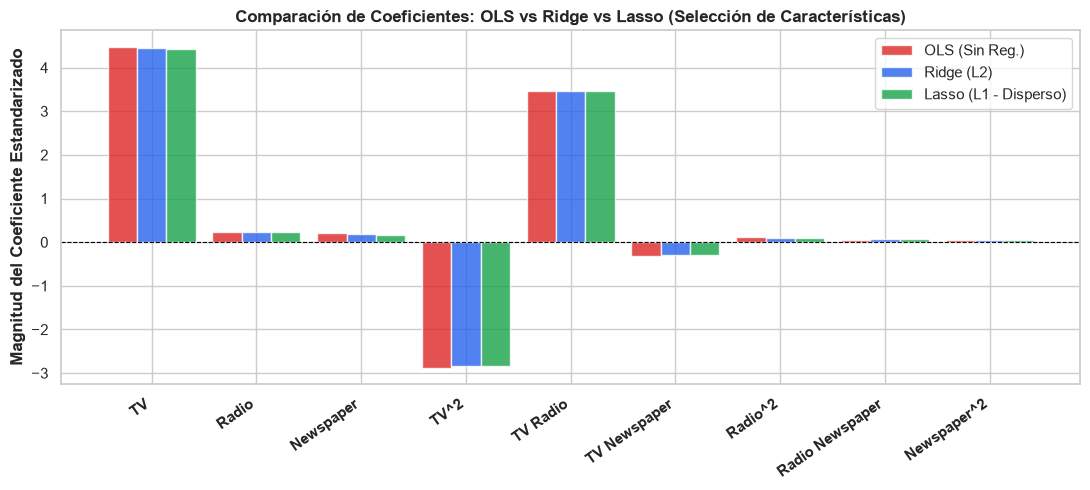

In [5]:
# Extraemos los coeficientes estandarizados aprendidos por cada modelo
feature_names = poly.get_feature_names_out(X_features)

# Ajuste OLS sobre datos estandarizados para comparación justa
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

ols_model = LinearRegression(fit_intercept=True).fit(X_train_poly_scaled, y_train)
ridge_coefs = ridge_cv.named_steps['ridgecv'].coef_
lasso_coefs = lasso_cv.named_steps['lassocv'].coef_

df_coefs = pd.DataFrame({
    'Característica': feature_names,
    'OLS (Sin Reg.)': ols_model.coef_,
    'Ridge (L2)': ridge_coefs,
    'Lasso (L1)': lasso_coefs
})

display(df_coefs)

# Gráfico de barras comparativo de coeficientes
plt.figure(figsize=(11, 5), dpi=100)
x_pos = np.arange(len(feature_names))
width = 0.28

plt.bar(x_pos - width, df_coefs['OLS (Sin Reg.)'], width, label='OLS (Sin Reg.)', color='#dc2626', alpha=0.8)
plt.bar(x_pos, df_coefs['Ridge (L2)'], width, label='Ridge (L2)', color='#2563eb', alpha=0.8)
plt.bar(x_pos + width, df_coefs['Lasso (L1)'], width, label='Lasso (L1 - Disperso)', color='#16a34a', alpha=0.8)

plt.xticks(x_pos, feature_names, rotation=35, ha='right', fontweight='bold')
plt.ylabel('Magnitud del Coeficiente Estandarizado', fontweight='bold')
plt.title('Comparación de Coeficientes: OLS vs Ridge vs Lasso (Selección de Características)', fontsize=12, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

print("🔍 Observación:")
print(f"Lasso anuló exactamente a 0 los coeficientes de {np.sum(lasso_coefs == 0)} características irrelevantes.")

In [6]:
# Evaluación de desempeño en el conjunto de prueba
y_pred_ols = ols_model.predict(X_test_poly_scaled)
y_pred_ridge = ridge_cv.predict(X_test_poly)
y_pred_lasso = lasso_cv.predict(X_test_poly)

res_eval = pd.DataFrame({
    'Modelo': ['OLS Polinomial', 'RidgeCV Polinomial', 'LassoCV Polinomial'],
    'R² en Test': [
        r2_score(y_test, y_pred_ols),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    'RMSE en Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_ols)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
})

display(res_eval)

               Modelo  R² en Test  RMSE en Test
0      OLS Polinomial    0.993273      0.487140
1  RidgeCV Polinomial    0.993368      0.483685
2  LassoCV Polinomial    0.993443      0.480928


---
##### 🛠️ Práctica 1: Expansión Cúbica ($d=3$) y Regularización con ElasticNet

**Contexto:**  
Al elevar el grado polinomial a $d=3$, el número de características aumenta drásticamente ($19$ variables derivadas de `TV`, `Radio` y `Newspaper`), lo que incrementa el riesgo de sobreajuste.

**Instrucciones:**
1. Construye una transformación polinomial de **grado 3** (`PolynomialFeatures(degree=3, include_bias=False)`).
2. Transforma los conjuntos `X_train` y `X_test`.
3. Ajusta un modelo de `ElasticNet(l1_ratio=0.5, random_state=42)` dentro de un pipeline con `StandardScaler()`.
4. Evalúa el nuevo $R^2$ y RMSE en el conjunto de prueba.
5. Compara los resultados frente al modelo polinomial de grado 2.

In [ ]:
# =========================================================================
# TU SOLUCIÓN: Polinomio de Grado 3 con ElasticNet
# =========================================================================

# 1. Crear transformación cúbica
# poly3 = PolynomialFeatures(degree=3, include_bias=False)
# X_tr_p3 = poly3.fit_transform(X_train)
# X_te_p3 = poly3.transform(X_test)

# 2. Pipeline con StandardScaler y ElasticNet
# pipe_elastic = make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42))
# pipe_elastic.fit(X_tr_p3, y_train)

# 3. Predicciones y métricas
# y_pred_el = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Transformación cúbica
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_tr_p3 = poly3.fit_transform(X_train)
X_te_p3 = poly3.transform(X_test)

print(f"Dimensiones con Polinomio Grado 3: {X_tr_p3.shape[1]} características generadas.")

# 2. Pipeline con StandardScaler y ElasticNet
pipe_elastic = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.05, l1_ratio=0.7, max_iter=10000, random_state=42)
)
pipe_elastic.fit(X_tr_p3, y_train)

# 3. Evaluación en prueba
y_pred_el = pipe_elastic.predict(X_te_p3)
r2_el = r2_score(y_test, y_pred_el)
rmse_el = np.sqrt(mean_squared_error(y_test, y_pred_el))

print("=" * 55)
print("🚀 RESULTADOS DE ELASTICNET (POLINOMIO GRADO 3):")
print("=" * 55)
print(f"• R² en Test:   {r2_el:.4f}")
print(f"• RMSE en Test: {rmse_el:.4f}")
print("=" * 55)
```
</details>

---
### 7. Resumen y Recursos Recomendados 📌

1. **Regresión Polinomial:** Permite capturar superficies de respuesta curvas manteniendo la linealidad en los parámetros.
2. **Regularización Ridge ($L_2$):** Penaliza la suma cuadrática $\lambda \sum \beta_j^2$, contrayendo coeficientes y reduciendo varianza ante alta multicolinealidad.
3. **Regularización Lasso ($L_1$):** Penaliza la suma absoluta $\lambda \sum |\beta_j|$, anulando coeficientes irrelevantes para selección automática de características.
4. **Estandarización Obligatoria:** Las técnicas de regularización son sensibles a la escala; siempre se debe aplicar `StandardScaler()`.

### 📚 Recursos Adicionales:
* **[Scikit-Learn Guide: Generalized Linear Models (Ridge & Lasso)](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification)**.
* **[Post-Selection Inference Caveats](https://stats.stackexchange.com/a/291641/253229)** — *Cross Validated / StackExchange*.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>